# <span style="color:rgb(213,80,0)">Create figures 6\-10</span>

old file was figures2024rev1


In [1]:
prin=0;
load ExportShifts.mat
Ntable=ExportShifts;
n=sum(Ntable{:,:},"all");
I=size(Ntable,1);


## Correspondence analysis based on all the obs

In [2]:
CorAna(Ntable)

Summary
             Singular_value    Inertia    Accounted_for    Cumulative
             ______________    _______    _____________    __________
    dim_1         0.27          0.07          0.50            0.50   
    dim_2         0.17          0.03          0.22            0.72   
    dim_3         0.14          0.02          0.13            0.85   
    dim_4         0.12          0.01          0.10            0.94   
    dim_5         0.07          0.01          0.04            0.98   
    dim_6         0.04          0.00          0.01            0.99   
    dim_7         0.04          0.00          0.01            1.00   
ROW POINTS
Results for dimension: 1
          Scores    CntrbPnt2In    CntrbDim2In
          ______    ___________    ___________
    AE    -0.09        0.02           0.15    
    AM     0.53        0.07           0.55    
    BA     0.26        0.03           0.26    
    BY     0.40        0.07           0.28    
    ER     1.75        0.02           0.53  


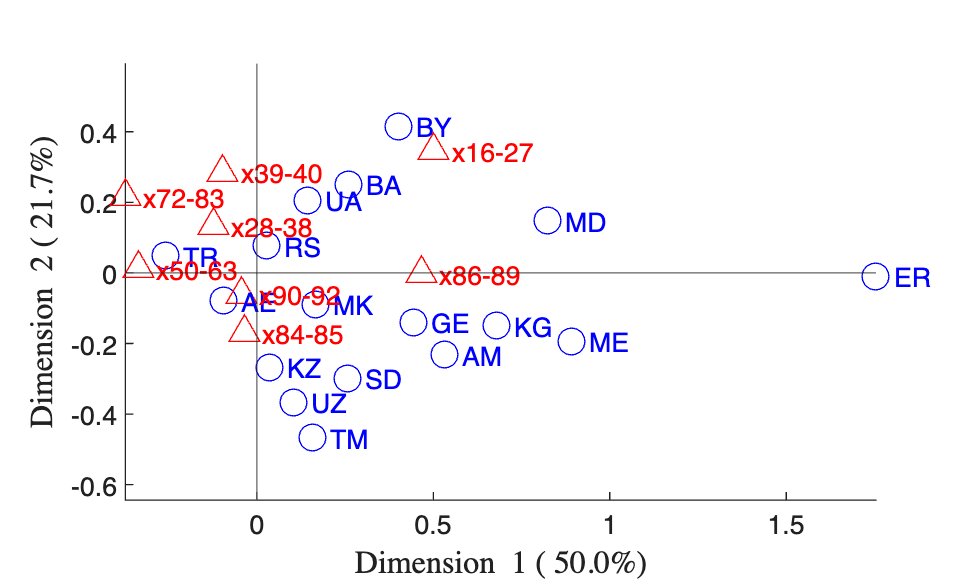

In [3]:
title('')

In [4]:
if prin==1
    % print to postscript
    print -depsc figs2024\SIca.eps;
end


## under H0

In [5]:
findEmp=struct;
% Generate nsimul contingency tables
findEmp.nsimul=1000; % 0;
% Under the null hypothesis of independence
findEmp.underH0=true;
% Store the nsimul robust distance sorted (for each row)
findEmp.StoreSim=true;


% Detect outlying rows using a simultaneous confidence level
conflev=1-0.01/I;
RAWH0=mcdCorAna(Ntable,'plots',0,'findEmpiricalEnvelope',findEmp, ...
    'conflev',conflev,'bdp',0.5);

Total estimated time to complete MCD:  0.27 seconds 
Finding empirical bands


## under H1

Example of findEmpiricalEnvelope a struct


In [6]:
findEmp=struct;
% Generate nsimul contingency tables
findEmp.nsimul=1000; % 0;
% Under the null hypothesis of independence
findEmp.underH0=false;
% Store the nsimul robust distance sorted (for each row)
findEmp.StoreSim=true;


% Detect outlying rows using a simultaneous confidence level
conflev=1-0.01/I;
RAWH1=mcdCorAna(Ntable,'plots',0,'findEmpiricalEnvelope',findEmp, ...
    'conflev',conflev,'bdp',0.5);

Total estimated time to complete MCD:  0.21 seconds 
Finding empirical bands


## Create left panel of Figure 7

In [7]:
plots=struct;
plots.minMD = true;
plots.inertia = false;
plots.addRowNames = true;


outFSH0=FSCorAna(RAWH0,'plots',plots,'init',round(n*0.25),'conflev',[0.05 0.95],'resc',false,'msg',0);

50  500  950   50  950


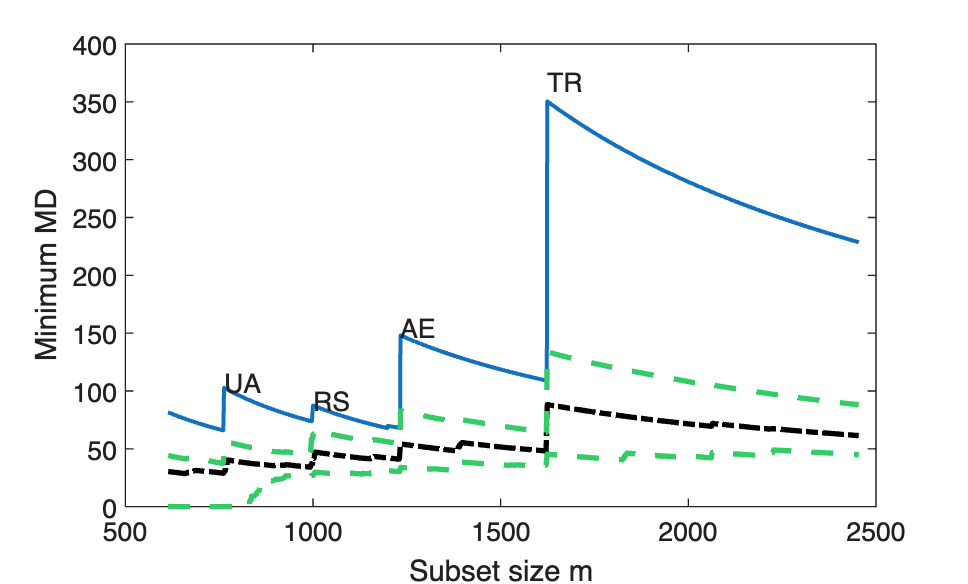

In [8]:
title('')
ylabel('Minimum MD')

In [9]:
h = findobj('Type','figure','Tag','pl_in');   % find figure handles with that tag
if ~isempty(h)
    close(h)
end


if prin==1
    % print to postscript
    print -depsc figs2024\SiFSH0.eps;
end


## Create right panel of Figure 7 (Under H0 rescaled)

In [10]:
plots=struct;
plots.minMD = true;
plots.inertia = false;
plots.addRowNames = true;


outFSH0=FSCorAna(RAWH0,'plots',plots,'init',round(n*0.25),'conflev',[0.05 0.95],'resc',true);

Creating empirical confidence band for minimum (weighted) Mahalanobis distance
50  500  950   50  950


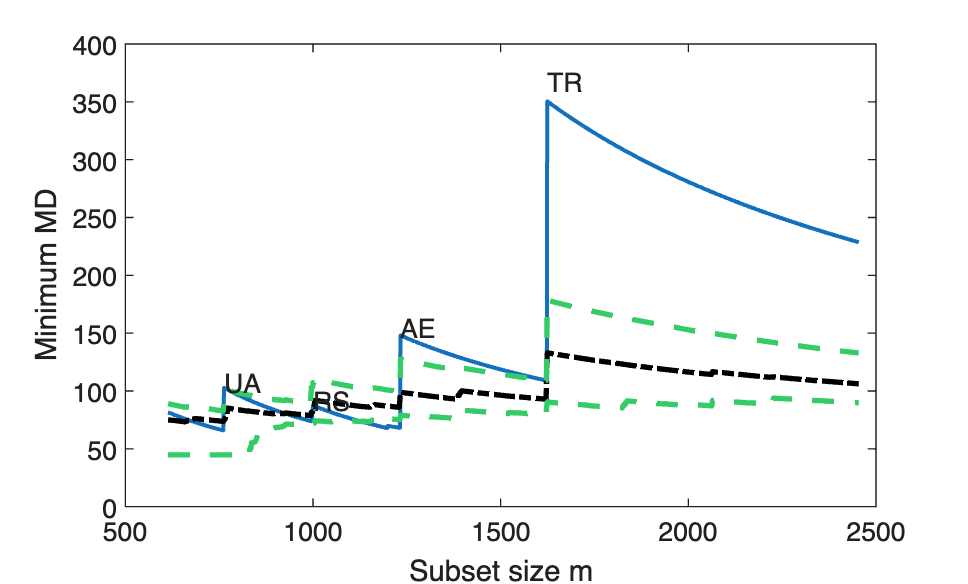

In [11]:
title('')
ylabel('Minimum MD')

In [12]:
if prin==1
    % print to postscript
    print -depsc figs2024\SiFSH0resc.eps;
end


## Create left panel of Figure 8: Under H1 not rescaled

In [13]:
FSCorAna(RAWH1,'plots',plots,'init',round(n*0.25),'conflev',[0.05 0.95],'resc',false);

Creating empirical confidence band for minimum (weighted) Mahalanobis distance
50  500  950   50  950


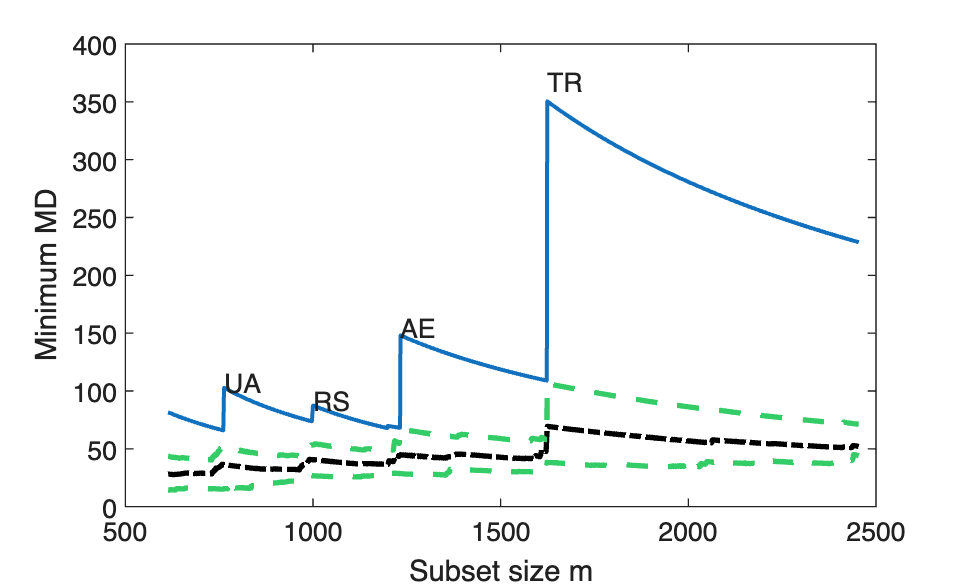

In [14]:
title('')
ylabel('Minimum MD')

In [15]:
% ylabel('')
if prin==1
    % print to postscript
    print -depsc figs2024\SiFSH1.eps;
end


## Create right panel of Figure 8: Under H1 rescaled

In [16]:
plots.addBonfLine=true;
outFSH1=FSCorAna(RAWH1,'plots',plots,'init',round(n*0.25),'conflev',0.90,'resc',true);

Creating empirical confidence band for minimum (weighted) Mahalanobis distance


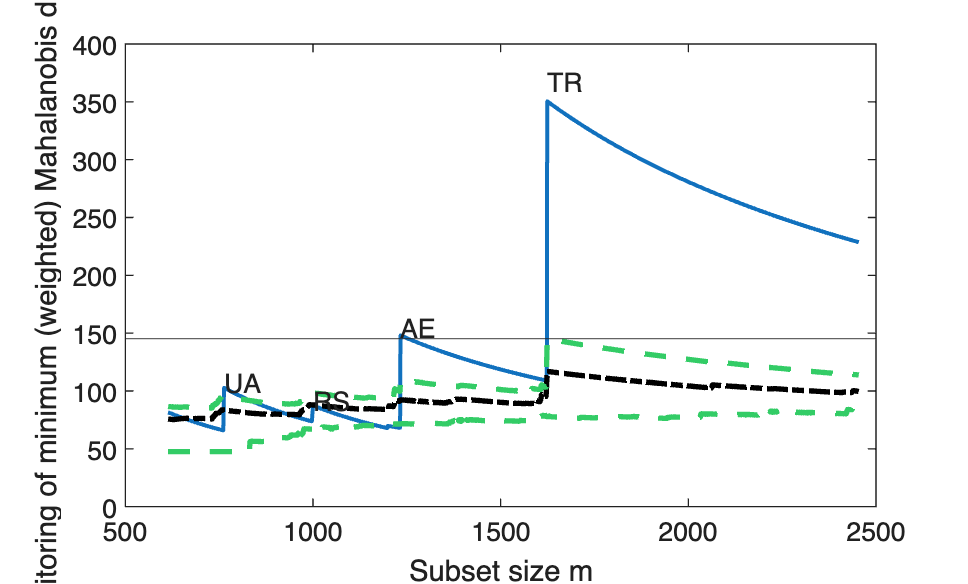

In [17]:
title('')

In [18]:
% ylabel('Minimum MD')
% ylim([40 400])
if prin==1
    % print to postscript
    print -depsc figs2024\SiFSH1resc1.eps;
end


## Figure 9: CA with two supplementary units

In [19]:
selsup={'TR', 'AE'};
selactive=setdiff(Ntable.Properties.RowNames,selsup);
Nsupr=Ntable(selsup,:);
Nactive=Ntable(selactive,:);
Sup=struct;
Sup.r=Nsupr;
outCorAna=CorAna(Nactive,'Sup',Sup);

Summary
             Singular_value    Inertia    Accounted_for    Cumulative
             ______________    _______    _____________    __________
    dim_1         0.24          0.06          0.35            0.35   
    dim_2         0.23          0.05          0.30            0.65   
    dim_3         0.18          0.03          0.20            0.85   
    dim_4         0.12          0.01          0.08            0.93   
    dim_5         0.09          0.01          0.05            0.98   
    dim_6         0.05          0.00          0.02            0.99   
    dim_7         0.03          0.00          0.01            1.00   
ROW POINTS
Results for dimension: 1
          Scores    CntrbPnt2In    CntrbDim2In
          ______    ___________    ___________
    AM    -0.29        0.05           0.28    
    BA     0.29        0.11           0.40    
    BY     0.32        0.11           0.22    
    ER    -0.09        0.00           0.00    
    GE    -0.12        0.01           0.13  


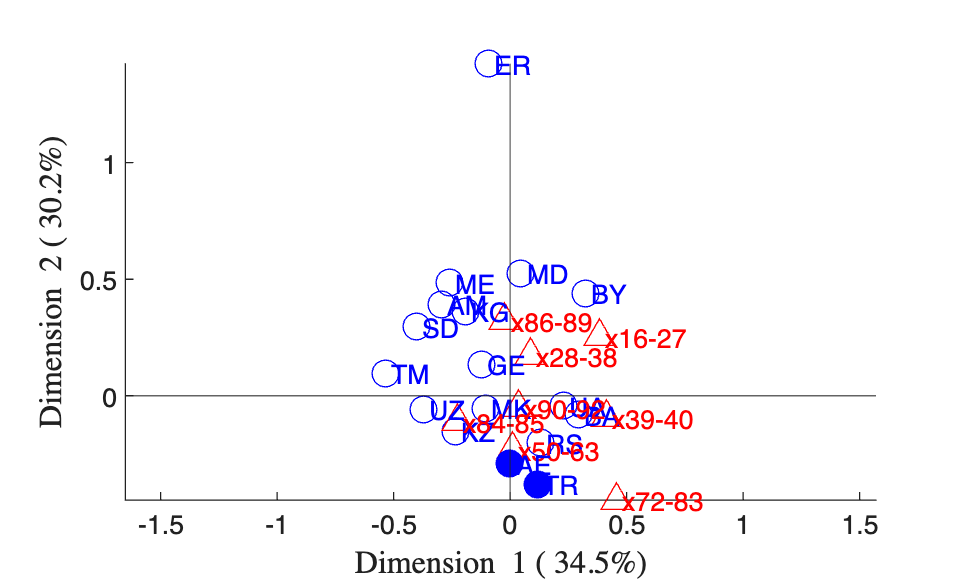

In [20]:
title('')

In [21]:


if prin==1
    % print to postscript
    print -depsc figs2024\SiCAwithSU.eps;
end


## ExportShifts

clear conflevSim=0.99; load ExportShifts.mat Ntable=ExportShifts; N=Ntable; %% Create Figure 10 conflev=0.95; % Example of findEmpiricalEnvelope a struct findEmp=struct; % Generate nsimul contingency tables findEmp.nsimul=1000; % Store the nsimul robust distance sorted (for each row) findEmp.StoreSim=true; % Under the null hypothesis of independence findEmp.underH0=true; % call to mcdCorAna RAWH0=mcdCorAna(N,'plots',0,'findEmpiricalEnvelope',findEmp,'bdp',0.5,'msg',0,'conflev',conflev); outFSH0=FSCorAna(RAWH0,'plots',0,'msg',0,'StoreSim',false,'conflev',conflevSim);

% Under the alternative hypothesis of dependence findEmp.underH0=false; % call to mcdCorAna RAWH1=mcdCorAna(N,'plots',0,'findEmpiricalEnvelope',findEmp,'bdp',0.5,'msg',0,'conflev',conflev); outFSH1=FSCorAna(RAWH1,'plots',0,'msg',0,'StoreSim',false,'conflev',conflevSim);

## Figure 10: Monitoring plots of inertia


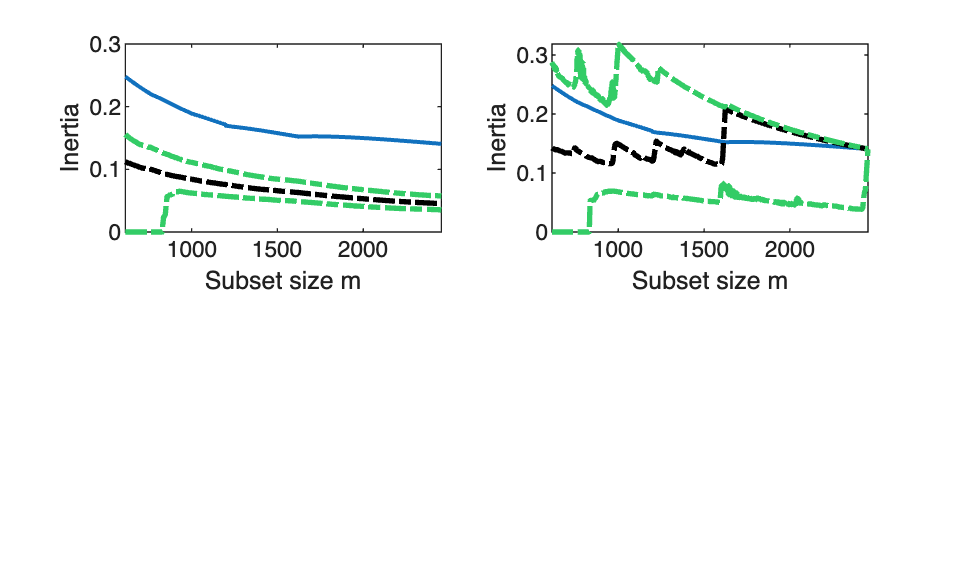

In [22]:
lwdreal=1.5;


figure
subplot(2,2,1)
plot(outFSH0.ine(:,1),outFSH0.ine(:,2),'LineWidth',lwdreal)


hold on
% include specified tag in the current plot
gine=outFSH0.ine(:,[1 3:end]);


lwdenv=2;
% Superimpose 50% envelope
line(gine(:,1),gine(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gine(:,1),gine(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gine(:,1),gine(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
ylabel('Inertia')
xlabel('Subset size m')


subplot(2,2,2)
plot(outFSH1.ine(:,1),outFSH1.ine(:,2),'LineWidth',lwdreal)


hold on
% include specified tag in the current plot
gine=outFSH1.ine(:,[1 3:end]);


lwdenv=2;
% Superimpose 50% envelope
line(gine(:,1),gine(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gine(:,1),gine(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gine(:,1),gine(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
ylabel('Inertia')
xlabel('Subset size m')

In [23]:
if prin==1
    print -depsc figs\I6.eps;
end